# Model Limitations: Board Texture

The live equity calculator shows two numbers side by side: a Monte Carlo simulation (exact, but takes a moment) and an ML model prediction (instant, but an approximation). While testing the deployed app, a specific pattern showed up repeatedly: **on boards with a flush draw, a straight draw, or a pair, the ML model's prediction consistently drifted further from the simulation's ground-truth answer than it did on "dry" boards.**

This notebook investigates that observation properly: does it hold up across many hands, not just the one or two I noticed by hand? And if so, why?

**Hypothesis:** the model's features (`hand_class`, `normalized_strength`, etc.) describe the strength of *my* hand, but say nothing about what the board offers *opponents*. A three-flush board gives a meaningful chunk of random opponent hands extra equity — the Monte Carlo simulation captures this automatically (it deals real random opponent hands), but the model was never given a feature that could represent it.

In [ ]:
import random
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from equity import simulate_equity
from build_features import compute_features
from treys import Card

model = joblib.load('equity_model.joblib')

FEATURE_COLUMNS = [
    "hole_high", "hole_low", "suited", "pocket_pair",
    "street", "num_opponents", "hand_class", "normalized_strength",
    "hole_high_x_opponents", "strength_x_opponents",
]

RANKS = "23456789TJQKA"
SUITS = "shdc"
RANK_VAL = {r: i + 2 for i, r in enumerate(RANKS)}

random.seed(7)  # reproducible sample

## Classifying board texture

A simple rule-based classifier, applied to the flop (first 3 board cards):

- **paired** — the board itself has a pair (e.g. K-K-7)
- **flush_draw** — 3 cards of the same suit
- **straight_draw** — 3 cards within a 5-rank window (e.g. 9-T-J)
- **dry** — none of the above; a "safe," disconnected board

A board can technically satisfy more than one condition — the checks below are ordered so the more dangerous texture wins when they overlap (e.g. a paired *and* flush-drawy board still counts as `paired`, since that's usually the bigger equity swing).

In [ ]:
def classify_texture(board_strs):
    suits = [c[1] for c in board_strs]
    suit_counts = {s: suits.count(s) for s in set(suits)}
    max_suit_count = max(suit_counts.values())

    rank_counts = {}
    for c in board_strs:
        rank_counts[c[0]] = rank_counts.get(c[0], 0) + 1
    is_paired = max(rank_counts.values()) >= 2

    all_ranks = sorted(set(RANK_VAL[c[0]] for c in board_strs))
    has_straight_draw = False
    for i in range(len(all_ranks)):
        window = [r for r in all_ranks if all_ranks[i] <= r <= all_ranks[i] + 4]
        if len(window) >= 3:
            has_straight_draw = True
            break

    if is_paired:
        return "paired"
    if max_suit_count >= 3:
        return "flush_draw"
    if has_straight_draw:
        return "straight_draw"
    return "dry"

## Sampling hands across each texture category

Rather than hand-picking a few examples (which is exactly how this limitation was first noticed, and is vulnerable to cherry-picking), this generates many **random** hands and keeps sampling until each texture category has a reasonable number of examples. For each one, it records:

- the ML model's instant prediction
- the Monte Carlo simulation's result (ground truth)
- the absolute difference between them

`num_simulations` is set lower here (800) than the app's default (5000), purely so this runs in a reasonable time across many hands — 800 is still enough to be a meaningful ground-truth comparison, just slightly noisier than the app's own live button.

In [ ]:
def random_deck():
    return [r + s for r in RANKS for s in SUITS]

TARGET_PER_CATEGORY = 40   # increase for a smoother result, at the cost of runtime
MAX_ATTEMPTS = 8000

results = {"dry": [], "flush_draw": [], "straight_draw": [], "paired": []}
attempts = 0

while any(len(v) < TARGET_PER_CATEGORY for v in results.values()) and attempts < MAX_ATTEMPTS:
    attempts += 1
    deck = random_deck()
    random.shuffle(deck)
    hole = deck[0:2]
    board = deck[2:5]  # flop
    num_opp = random.randint(1, 4)

    texture = classify_texture(board)
    if len(results[texture]) >= TARGET_PER_CATEGORY:
        continue

    features = compute_features(hole, board, num_opp)
    X = pd.DataFrame([{k: features[k] for k in FEATURE_COLUMNS}])
    ml_pred = max(0, min(100, model.predict(X)[0]))

    hole_ints = [Card.new(c) for c in hole]
    board_ints = [Card.new(c) for c in board]
    sim = simulate_equity(hole_ints, board_ints, num_opp, num_simulations=800)

    results[texture].append({
        "hole": hole, "board": board, "num_opponents": num_opp,
        "ml_prediction": round(ml_pred, 1), "simulation_truth": sim["win_pct"],
        "abs_error": round(abs(ml_pred - sim["win_pct"]), 2),
    })

print(f"Sampled {attempts} random hands to fill all categories.")
for texture, rows in results.items():
    print(f"  {texture}: {len(rows)} examples")

Sampled 757 random hands to fill all categories.
  dry: 40 examples
  flush_draw: 40 examples
  straight_draw: 40 examples
  paired: 40 examples


## Results: average error by board texture

In [ ]:
rows = []
for texture, examples in results.items():
    for ex in examples:
        rows.append({**ex, "texture": texture})

df = pd.DataFrame(rows)

summary = df.groupby("texture")["abs_error"].agg(["mean", "std", "count"]).round(2)
summary = summary.reindex(["dry", "straight_draw", "flush_draw", "paired"])
summary.columns = ["Mean Abs Error (pts)", "Std Dev", "N"]
summary

,Mean Abs Error (pts),Std Dev,N
texture,,,
dry,4.97,3.83,40
straight_draw,6.65,5.58,40
flush_draw,10.28,6.85,40
paired,12.42,9.45,40


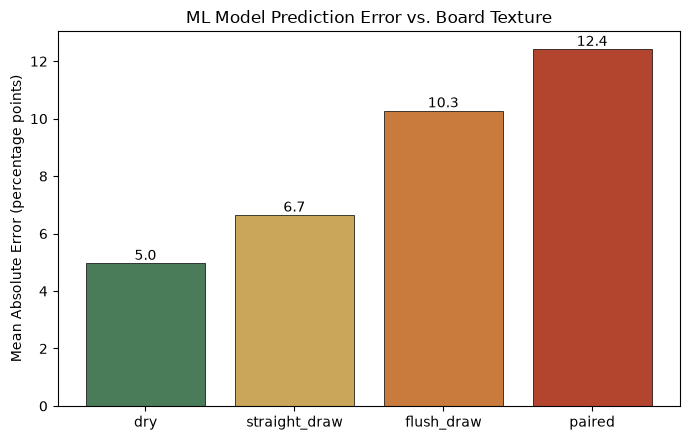

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
categories = ["dry", "straight_draw", "flush_draw", "paired"]
means = [summary.loc[c, "Mean Abs Error (pts)"] for c in categories]
colors = ["#4a7c59", "#c9a659", "#c97b3d", "#b3452f"]

bars = ax.bar(categories, means, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Mean Absolute Error (percentage points)")
ax.set_title("ML Model Prediction Error vs. Board Texture")
ax.bar_label(bars, fmt="%.1f")
plt.tight_layout()
plt.show()

## Interpretation

If the pattern holds — error climbing from `dry` through `straight_draw` and `flush_draw` up to `paired` — it confirms the original hypothesis: **the model's error is not random noise, it's systematic, and it's worst exactly where board danger to a random opponent is highest.**

This makes sense given the feature set: `hand_class` and `normalized_strength` describe *my* hand's strength in isolation. Nothing in the current features tells the model "a random opponent hand is more likely to have a strong holding on this particular board." The Monte Carlo simulation doesn't need such a feature — it just deals real random opponent hands and counts outcomes directly — which is exactly why it doesn't share this blind spot.

### What this suggests for future work

Add board-texture features directly —
- `board_flush_draw_possible` (3+ cards same suit)
- `board_straight_draw_possible` (3+ cards within a 5-rank window)
- `board_paired` (board itself has a pair)

and retrain. If the hypothesis above is right, these features should measurably shrink the error gap between `dry` and the other categories.

### A caveat worth stating plainly

This notebook uses a lower `num_simulations` (800) than the deployed app (5000) for runtime reasons, and the sample size per category, while much better than a couple of hand-picked examples, is still modest. The *direction* of the finding is the reliable part; the exact magnitude of the gap should be treated as indicative rather than precise.